In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from utils.bivaraite_boxplot import plot_segmented_boxplot
from utils.cat_num_dep import hub_pruebas_num_cat
from utils.plotting import EDAPlotter
from utils.triple_plot import normality_report

In [2]:
df = pd.read_csv("../data/datos_inmobiliarios_clean.csv")

In [3]:
plotter = EDAPlotter(df)

In [4]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,pub_month,mod_month,log_price_amount
0,casa,8.800000e+08,736000.00,5.500000e+06,160.0000,151.0,3.0,3.0,2,4.0,...,Suba,UB. Hacienda Cordoba Niza,4.711642,-74.062946,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,Particular / Venta Directa,Particular,2023-01,2026-06,20.595432
1,casa,6.500000e+08,196727.91,4.237288e+06,153.4000,153.4,4.0,2.0,1,3.0,...,Barrios Unidos,Benjamin Herrera,4.655459,-74.073723,Baño Auxiliar|Colegios / Universidades|Estudio...,Particular / Venta Directa,Particular,2023-01,2026-07,20.292483
2,casa,6.250000e+08,643500.00,5.208333e+06,120.0000,120.0,4.0,3.0,2,5.0,...,Usaquen,Lagos DE Torca,4.764007,-74.042742,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,Particular / Venta Directa,Particular,2023-02,2026-06,20.253262
3,apartamento,4.700000e+08,560000.00,8.392857e+06,56.0000,58.0,1.0,2.0,1,4.0,...,Usaquen,Cedritos,4.721554,-74.036146,Ascensor|Barra estilo americano|Baño Auxiliar|...,Particular / Venta Directa,Particular,2023-03,2026-07,19.968243
4,casa,3.300000e+09,1317625.80,8.230622e+06,369.7528,350.0,4.0,3.0,2,6.0,...,Suba,San Jose DE Bavaria,4.769128,-74.061616,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03,2026-06,21.917188


In [5]:
df.columns

Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'age_bracket_code',
       'age_bracket_label', 'construction_state', 'city', 'locality',
       'neighborhood', 'latitude', 'longitude', 'amenities', 'agency_name',
       'publisher_type', 'pub_month', 'mod_month', 'log_price_amount'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20253 entries, 0 to 20252
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       20253 non-null  str    
 1   price_amount        20253 non-null  float64
 2   admin_fee           20253 non-null  float64
 3   price_per_m2        20253 non-null  float64
 4   area_built_m2       20253 non-null  float64
 5   area_private_m2     20253 non-null  float64
 6   bedrooms            20253 non-null  float64
 7   bathrooms           20253 non-null  float64
 8   parking_spaces      20253 non-null  int64  
 9   stratum             20253 non-null  float64
 10  floor               20253 non-null  int64  
 11  age_bracket_code    20253 non-null  float64
 12  age_bracket_label   20253 non-null  str    
 13  construction_state  20253 non-null  str    
 14  city                20253 non-null  str    
 15  locality            20253 non-null  str    
 16  neighborhood   

Después del proceso de limpieza, la base utilizada para el análisis bivariado contiene 20.253 observaciones y 25 variables.

Todas las variables presentan 20.253 valores no nulos, por lo que en esta etapa no existen datos faltantes que puedan afectar directamente las comparaciones entre el precio y los posibles predictores.

# Against Y (`price_amount`)

## Boxplots

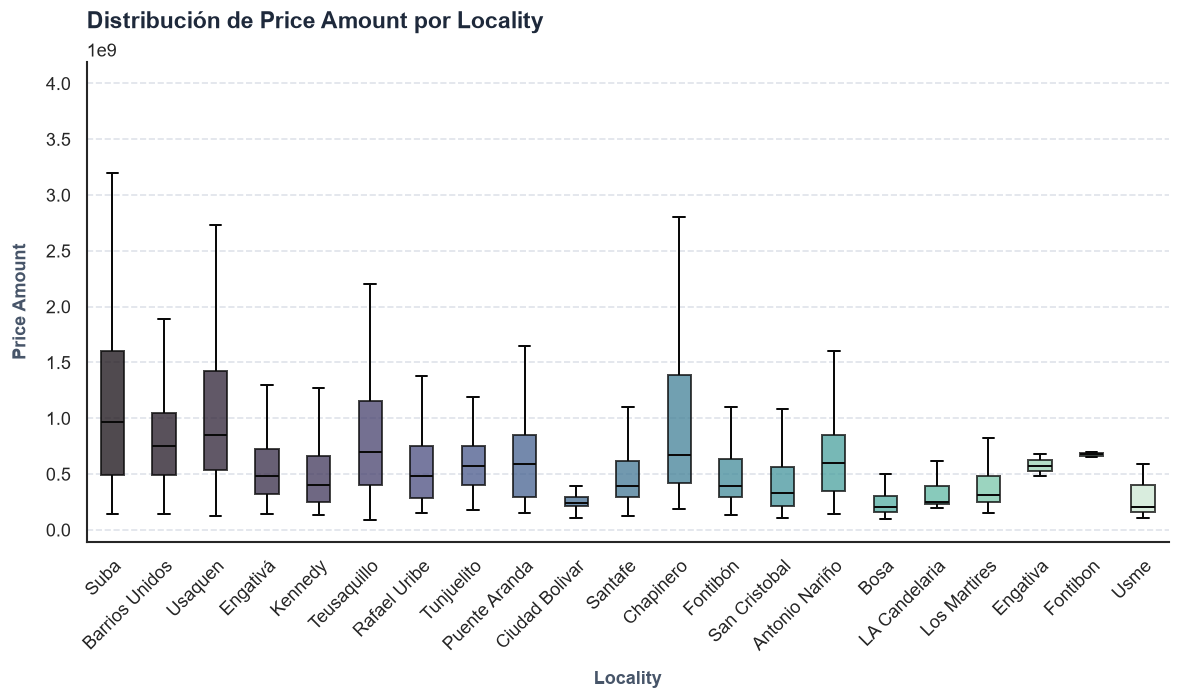

In [7]:
plot_segmented_boxplot(
    df, "price_amount", "locality", show_points=False, x_rotation=45
)

Las localidades con la vivienda con menor precio son Bosa y Ciudad Bolivar, mientras que Suba, Usaquen y Chapinero en general tienen viviendas más costosas, un resultado esperable considerando la coyuntura social de cada localidad.

Sin embargo, esta comparación es descriptiva y no permite atribuir las diferencias exclusivamente a la localidad, dado que también pueden intervenir características como área, estrato o tipo de inmueble.

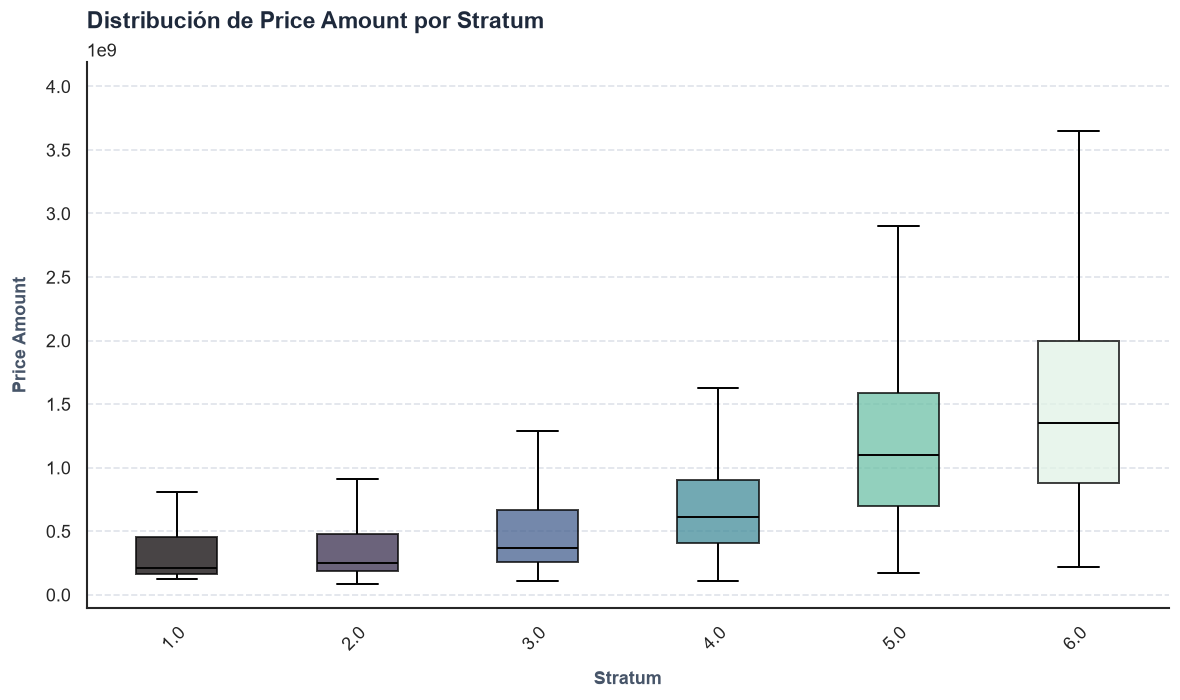

In [8]:
plot_segmented_boxplot(
    df, "price_amount", "stratum", show_points=False, x_rotation=45
)

Con el gráfico observado podemos identificar una asociación positiva clara entre estrato y precio: a medida que aumenta el estrato, las distribuciones y medianas del precio también. Este va a ser el primer respaldo de la hipotesis 1.

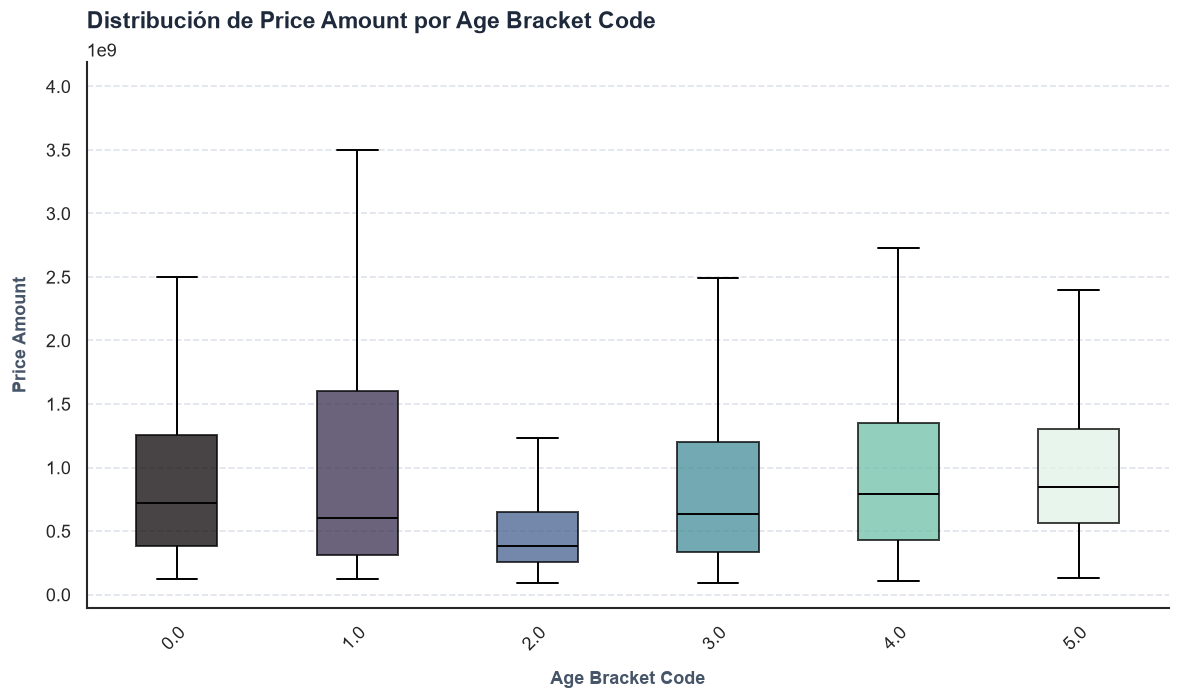

In [9]:
plot_segmented_boxplot(
    df, "price_amount", "age_bracket_code", show_points=False, x_rotation=45
)

Los precios cambian entre categorías de antigüedad, pero no se observa una tendencia claramente creciente o decreciente. La relación con el precio parece no ser completamente lineal.

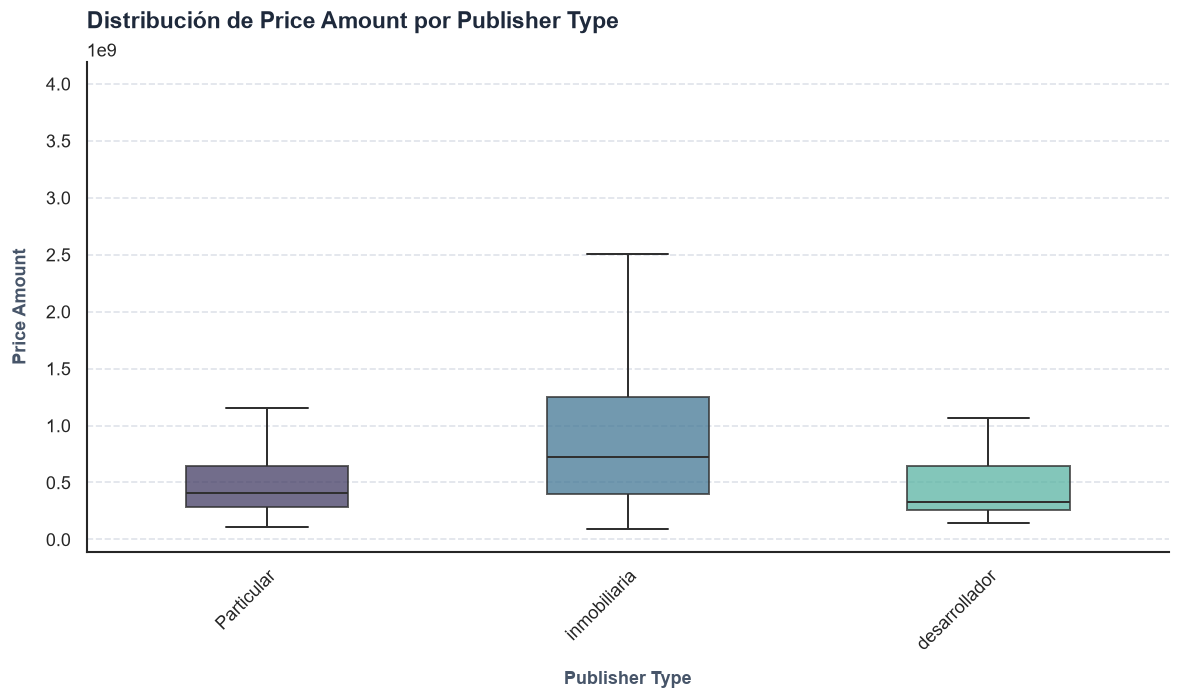

In [10]:
plot_segmented_boxplot(
    df, "price_amount", "publisher_type", show_points=False, x_rotation=45
)

Los inmuebles publicados por inmobiliarias presentan, en general, precios más altos y mayor dispersión que los publicados por particulares o desarrolladores.

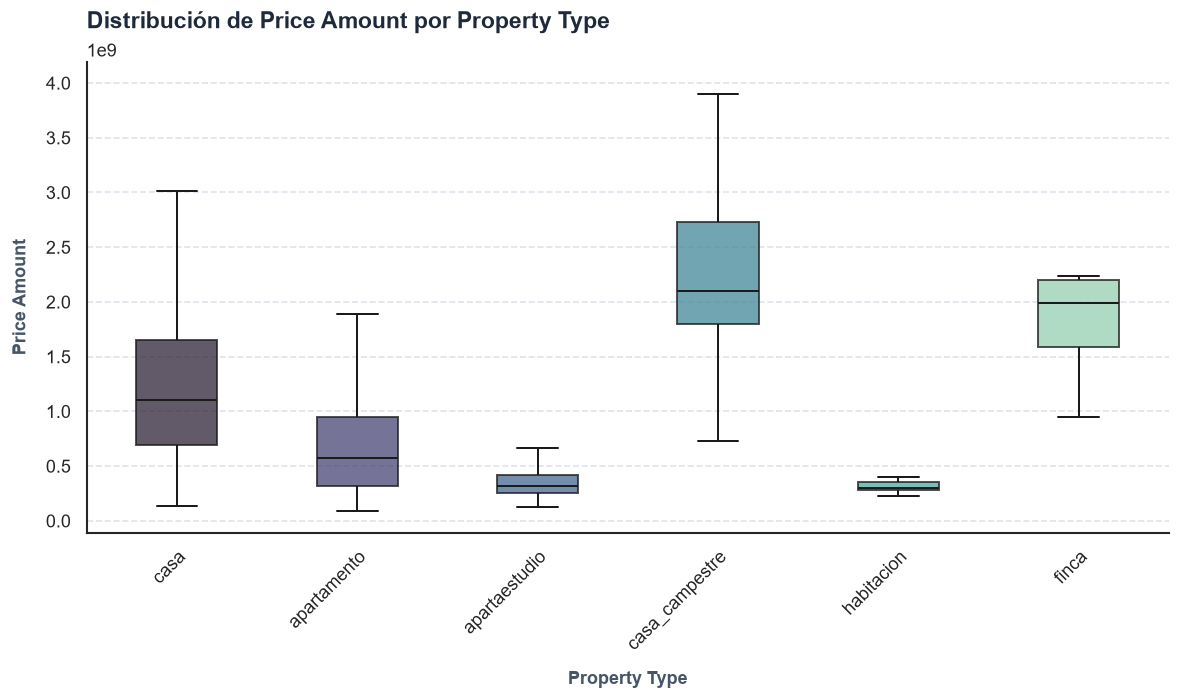

In [11]:
plot_segmented_boxplot(
    df, "price_amount", "property_type", show_points=False, x_rotation=45
)

El precio varía según el tipo de inmueble. Las casas campestres y fincas presentan precios más altos, mientras que apartamentos y apartaestudios muestran valores menores. 

Esto debe tomarse con cuidado puesto que hay pocas fincas y casas campestres en la muestra. A futuro probablemente se agrupen como "Otros".

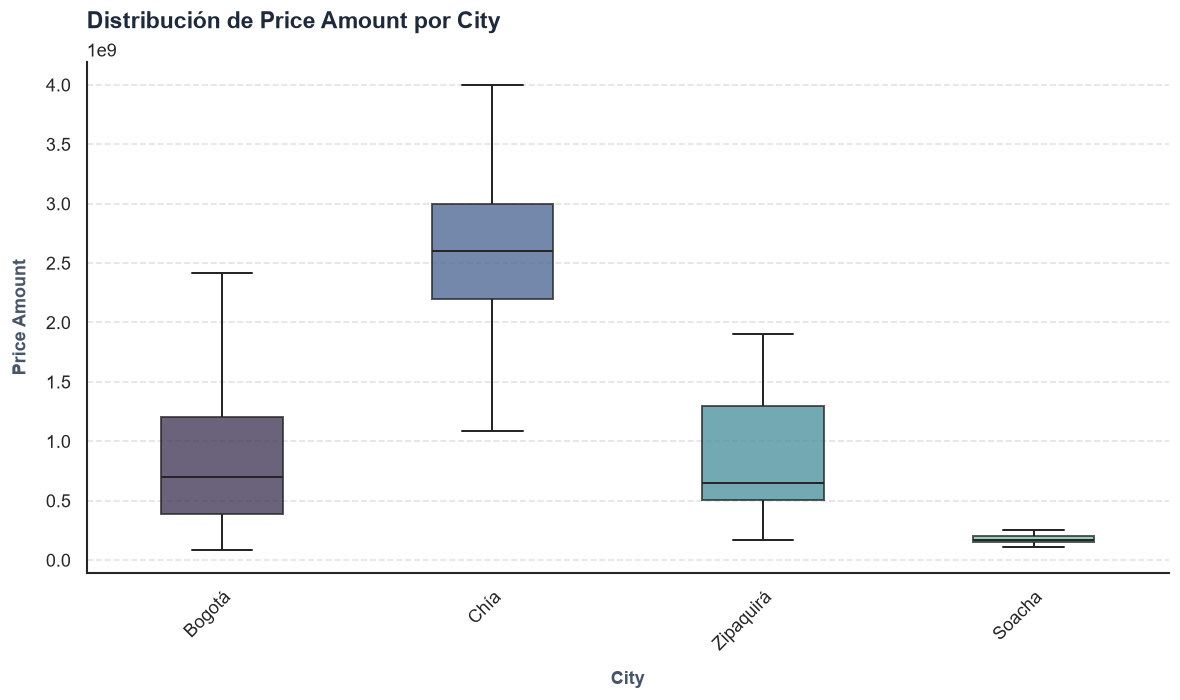

In [12]:
plot_segmented_boxplot(df, "price_amount", "city", show_points=False)

Chía presenta los precios más altos y Soacha los más bajos. Bogotá muestra una mayor dispersión, lo que refleja una mayor variedad de precios. Hay que tener precaución en su análisis ya que de chia solo hay 193 registros y 149 de soacha.

## Scatter plots

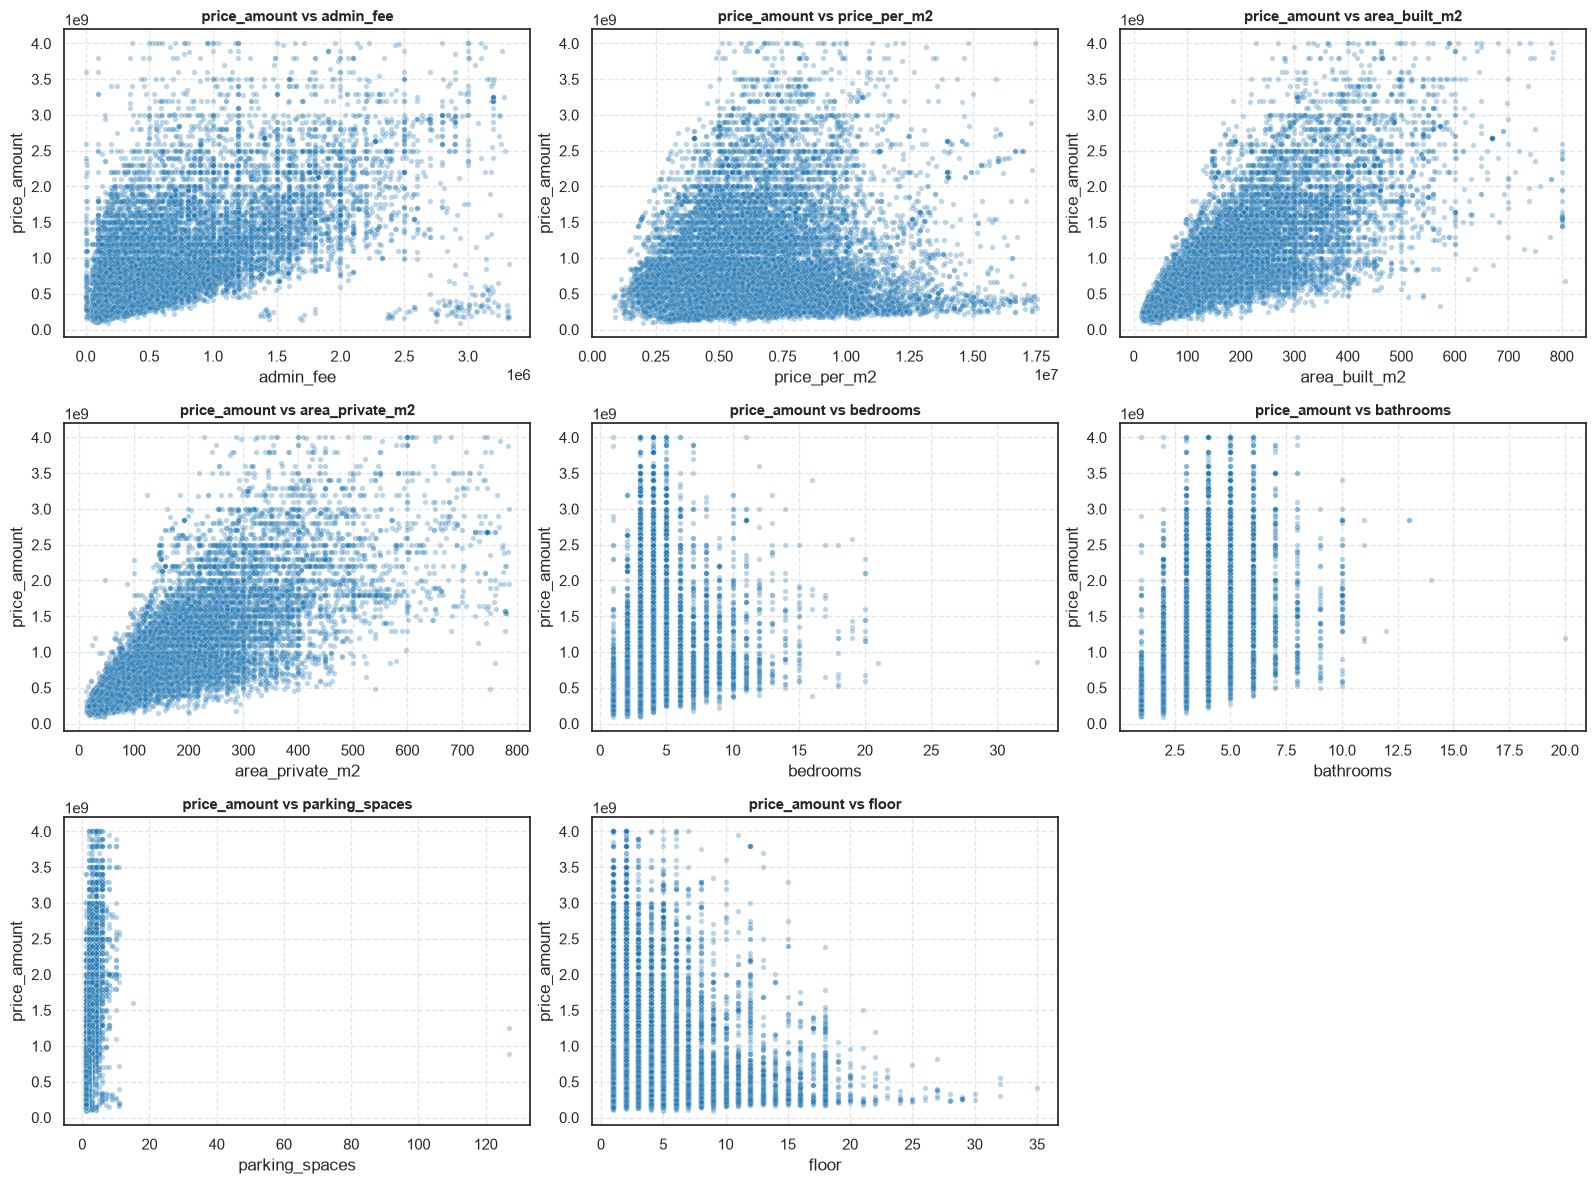

In [13]:
target = "price_amount"
predictors = [
    "admin_fee",
    "price_per_m2",
    "area_built_m2",
    "area_private_m2",
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "floor",
]

n_cols = 3
n_rows = math.ceil(len(predictors) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()


for i, col in enumerate(predictors):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        alpha=0.3,
        s=15,
        color="#1f77b4",
    )

    axes[i].set_title(f"{target} vs {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
    axes[i].grid(True, linestyle="--", alpha=0.5)


for i in range(len(predictors), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Los gráficos de dispersión permiten observar asociaciones especialmente marcadas entre el precio y variables como el área construida y el área privada. Otras variables muestran relaciones más débiles o una alta dispersión.

## Hypothesis test


In [14]:
df.columns

Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'age_bracket_code',
       'age_bracket_label', 'construction_state', 'city', 'locality',
       'neighborhood', 'latitude', 'longitude', 'amenities', 'agency_name',
       'publisher_type', 'pub_month', 'mod_month', 'log_price_amount'],
      dtype='str')

In [15]:
cat_vars = [
    "property_type",
    "stratum",
    "age_bracket_code",
    "publisher_type",
    "city",
]

In [16]:
hub_pruebas_num_cat(df, "price_amount", cat_vars)

,var_numerica,var_categorica,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,decision,conclusion,post_hoc
0,price_amount,property_type,6,Kruskal-Wallis (H),4203.5655,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,apartaestudio vs apartamento (p=0.0000); apart...
1,price_amount,stratum,6,Kruskal-Wallis (H),8257.5870,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,1.0 vs 3.0 (p=0.0033); 1.0 vs 4.0 (p=0.0000); ...
2,price_amount,age_bracket_code,6,Kruskal-Wallis (H),1882.6890,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,0.0 vs 2.0 (p=0.0000); 0.0 vs 3.0 (p=0.0080); ...
3,price_amount,publisher_type,3,Kruskal-Wallis (H),400.4959,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,Particular vs inmobiliaria (p=0.0000); desarro...
4,price_amount,city,4,Kruskal-Wallis (H),841.6202,0.0,no,no,Se rechaza H0,Dependencia: la numérica difiere entre categorías,Bogotá vs Chía (p=0.0000); Bogotá vs Soacha (p...


**H₀:** La distribución del precio es igual entre las categorías de la variable analizada.

**H₁:** La distribución del precio difiere en al menos una de las categorías.


Con un nivel de significancia de 0.05, en todas las variables categóricas se obtiene un p-valor menor a 0.05, por lo que se rechaza la hipótesis nula.

Esto indica que existen diferencias estadísticamente significativas en la distribución del precio entre al menos algunas de las categorías de `property_type`, `stratum`, `age_bracket_code`, `publisher_type` y `city`.

## Heat map

d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:8491: UserWarning: Column 'stratum' is numeric but has only 6 distinct value(s), so it is treated as categorical. Override with treat_as={'stratum': 'numeric'} or the constructor's as_numeric=['stratum'].
  kind = self.resolve_kind(frame[column], treat.get(column))
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:8491: UserWarning: Column 'age_bracket_code' is numeric but has only 6 distinct value(s), so it is treated as categorical. Override with treat_as={'age_bracket_code': 'numeric'} or the constructor's as_numeric=['age_bracket_code'].
  kind = self.resolve_kind(frame[column], treat.get(column))
D:\Temp\ipykernel_23344\3529653998.py:1: UserWarning: corr_heatmap excluded 2 numeric-but-low-cardinality column(s) (stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.cor

<Axes: >

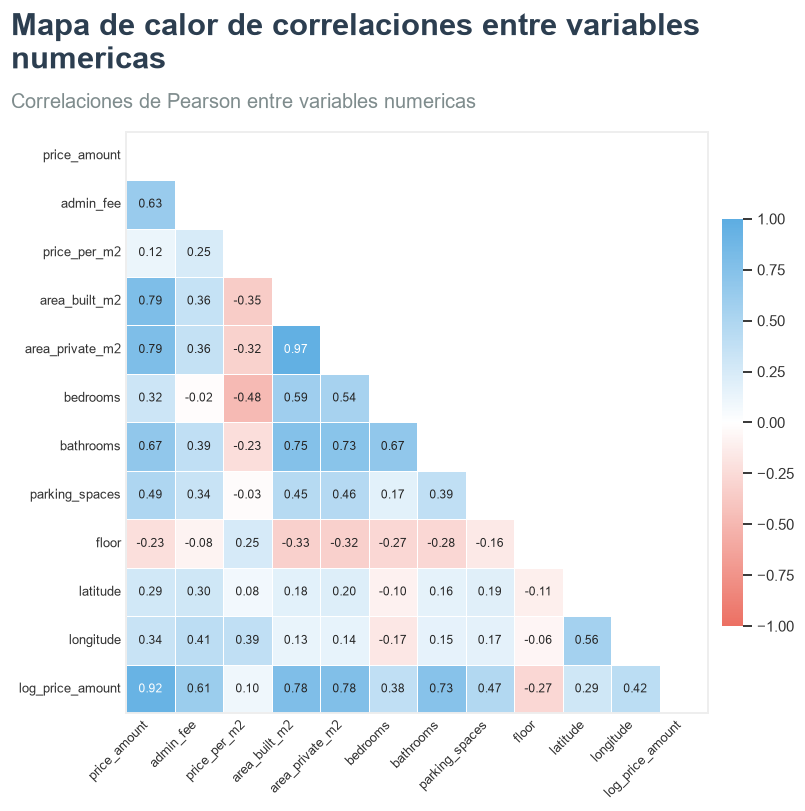

In [17]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Pearson entre variables numericas",
    annot=True,
    method="pearson",
)

Después de la limpieza se observan asociaciones lineales más claras que en la base original, por lo que se refuta la hipotesis hecha en clase. En particular, el precio presenta una relación positiva importante con el área construida y el área privada. 

Al mismo tiempo, estas dos variables están fuertemente relacionadas entre sí, por lo que una posible multicolinealidad se evaluará posteriormente mediante el VIF.

D:\Temp\ipykernel_23344\4115540453.py:1: UserWarning: corr_heatmap excluded 2 numeric-but-low-cardinality column(s) (stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.corr_heatmap(


<Axes: >

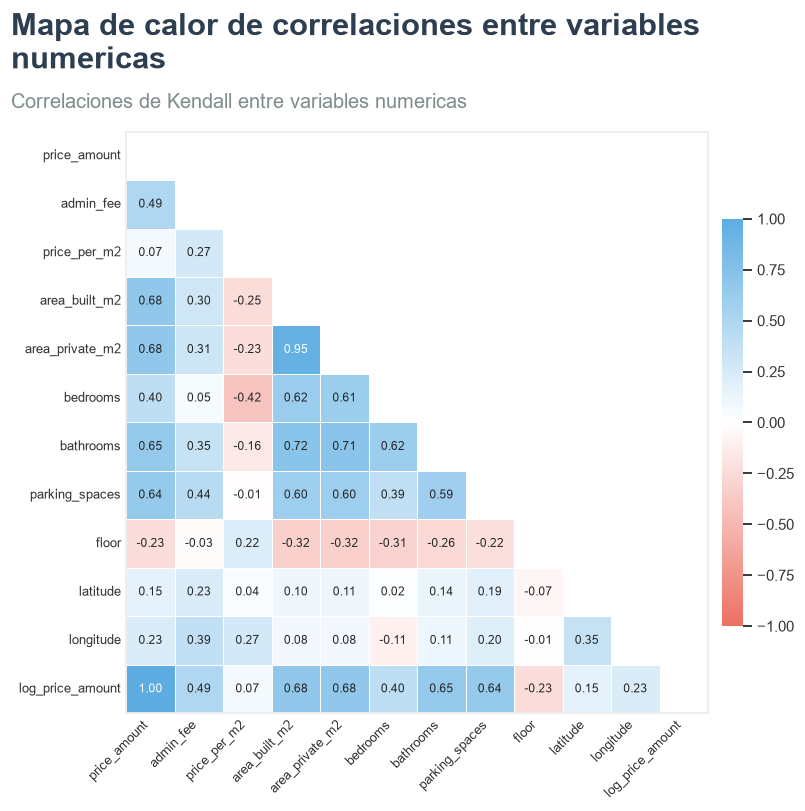

In [18]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Kendall entre variables numericas",
    method="kendall",
    annot=True,
)

El precio presenta una relación positiva principalmente con el área construida, el área privada, los baños y los parqueaderos.

También se observa una relación muy alta entre el área construida y el área privada, lo que podría indicar información repetida entre ambas variables.

# Between feature variables

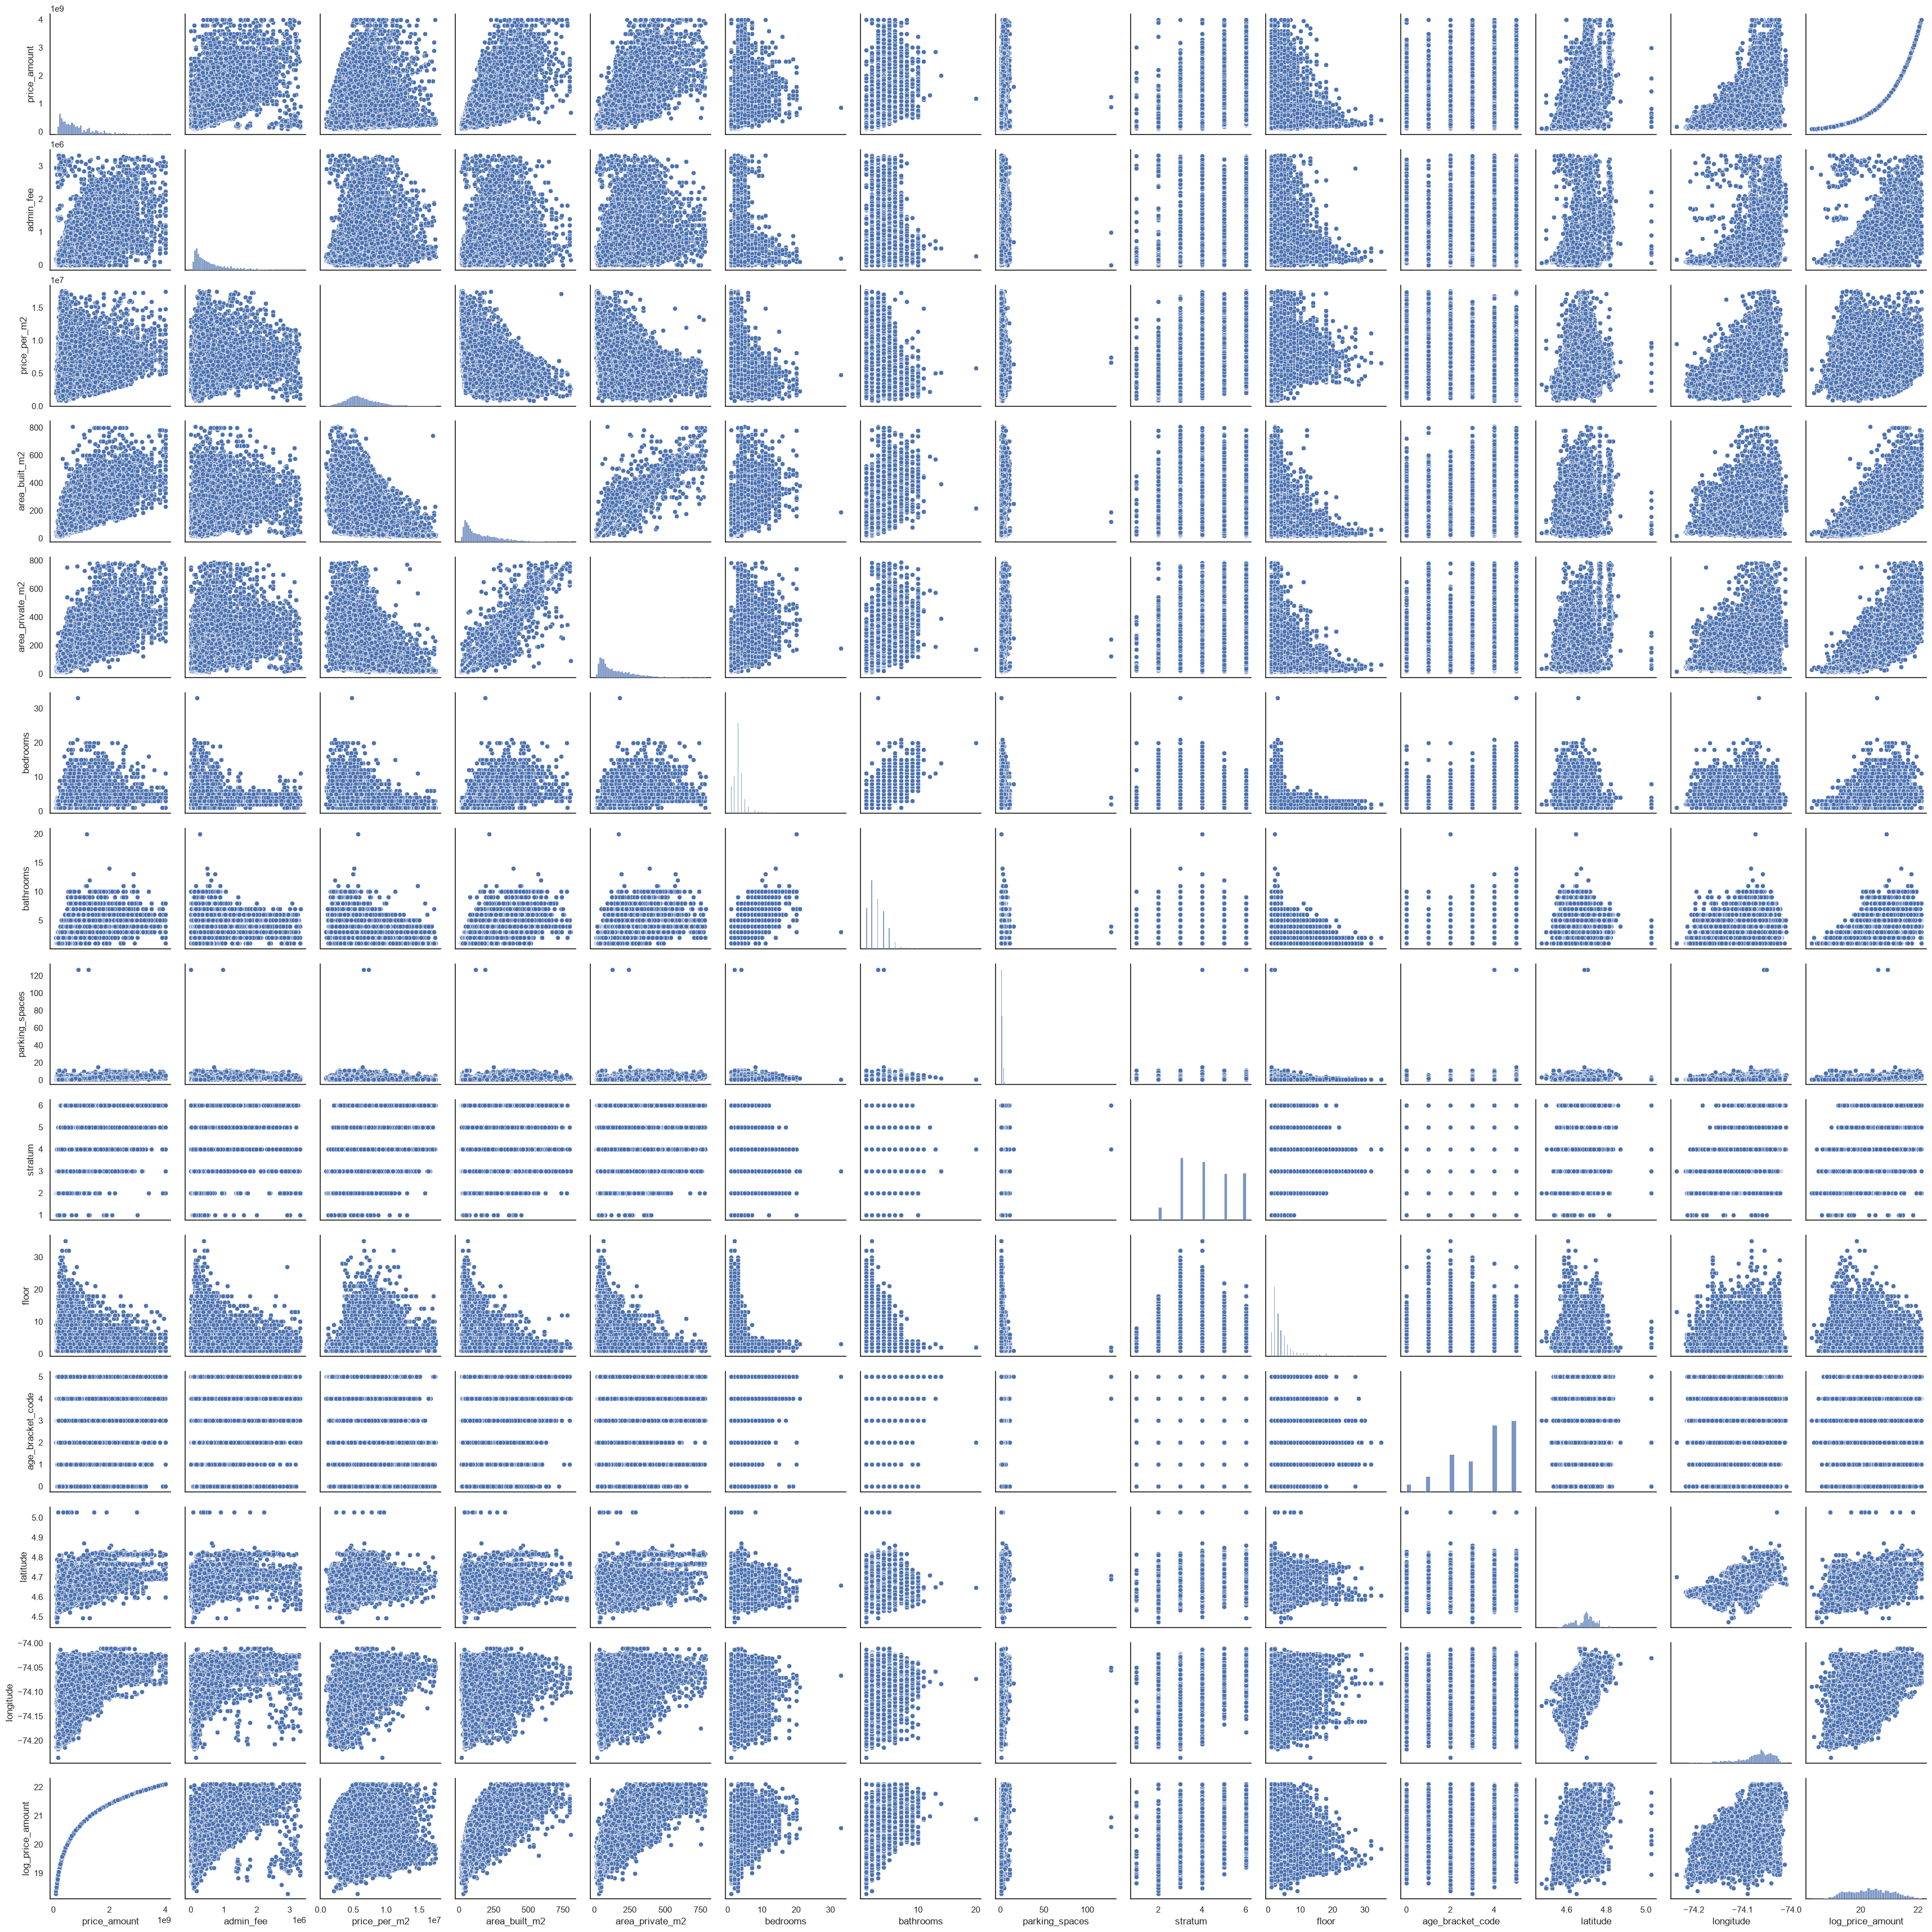

In [19]:
sns.pairplot(df)

plt.show()

Entre las variables predictoras se observan algunas relaciones fuertes, especialmente entre las variables de área y otras características físicas del inmueble.

Estas asociaciones pueden indicar información redundante entre algunos predictores, por lo que posteriormente se revisará la multicolinealidad mediante correlaciones y VIF.